# Detecting "Repetitive Taks" using Assets

A core part of this project is to define what constitutes a 'repetitive task' (i.e. a specific maintenance issue that has been called upon for fixing multiple times in a short timeframe). By identifying repetitive tasks, we can infer what maintenance tickets were completed successfully (fixed the underlying issue), and which were not (underlying issue persists). In this notebook, we will experiment by defining a repetitive task using 'asset' information tied to each ticket.

### Methodology
We identified corrective maintenance tasks that occur repeatedly for the same asset within a *90-day interval*. We include only tasks with `WORK_TASK_STATUS == 'Completed'` (tasks that have been followed through) and `TASK_TYPE == 'Corrective'` (tasks that are called to fix rather than prevent an issue). 

To track which tasks refer to the same asset, we use the `ASSET_ID` column that corresponds to each work task (`'WORK_TASK_ID'`). Formally, a task is defined as a 'repetitive task' in this notebook if both the task itself and a subsequent task:
1. Are called within 90 days of each other,
2. Performed on the **same asset** (same `'ASSET_ID'`),
3. Both **corrective** tasks,(`TASK_TYPE == 'Corrective'`), and
4. have both been marked as completed (`WORK_TASK_STATUS == 'Completed'`)

In [1]:
import sys
import os
sys.path.append(os.path.abspath('../utils'))

import pandas as pd
import numpy as np
from data_aggregation_tools import merge_tickets_assets, convert_cols_to_datetime

# Load in data (from data folder at root)

df_tickets = pd.read_csv("../../data/V_OM_WORK_TASK.csv")
df_assets = pd.read_csv("../../data/V_OM_WORK_TASK_ASSET.csv")

# Generate merged tickets / assets file
df_tickets_assets = merge_tickets_assets(df_tickets=df_tickets, df_assets=df_assets)

df_tickets_assets = convert_cols_to_datetime(df_tickets_assets)

print(f"shape of df_tickets: {df_tickets.shape}")
print(f"shape of df_assets: {df_assets.shape}")
print(f"shape of df_tickets_assets: {df_tickets_assets.shape}")

/var/folders/y2/tsyh3wpj3mj7zcv4hfd0knl40000gn/T/ipykernel_11076/2922389218.py:11: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_tickets = pd.read_csv("../../data/V_OM_WORK_TASK.csv")
/var/folders/y2/tsyh3wpj3mj7zcv4hfd0knl40000gn/T/ipykernel_11076/2922389218.py:12: DtypeWarning: Columns (0,3,4,5,6,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df_assets = pd.read_csv("../../data/V_OM_WORK_TASK_ASSET.csv")


shape of df_tickets: (227205, 47)
shape of df_assets: (316257, 9)
shape of df_tickets_assets: (316257, 55)


In [2]:
pd.set_option('display.max_columns', None)

df_tickets_assets.head()


,WORK_TASK_ID,WORK_TASK_NAME_ticket,WORK_TASK_STATUS_ticket,RICE_WORK_STATUS,ASSIGNMENT_STATUS,DESCRIPTION,TASK_TYPE,TASK_PRIORITY,REQUEST_CLASS,SERVICE_CLASS,PRIMARY_LOCATION,PROPERTY,BUILDING,FLOOR,SPACE,GEOGRAPHY_LOOKUP,CUSTOMER_ORGANIZATION,CUSTOMER_COMPANY,CUSTOMER_DIVISION,CUSTOMER_DEPARTMENT,RESPONSIBLE_ORGANIZATION_NAME,ORGANIZATION_TYPE,RESPONSIBLE_ORGANIZATION_PATH,RESPONSIBLE_PERSON_NAME,RESPONSIBLE_PERSON_EMAIL,RESPONSIBLE_PERSON_WORKPHONE,BASELINE_START_LTZ,BASELINE_END_LTZ,ASSIGNED_DATE_LTZ,PLANNED_START_LTZ,PLANNED_END_LTZ,PLANNED_FOLLOW_UP_DATE_LTZ,PLANNED_WORKING_DAYS,PLANNED_COST,ACTUAL_START_LTZ,ACTUAL_END_LTZ,RICE_ACTUAL_COST,REVERSAL,BILLING_TYPE,ACCOUNTING_HOLD,ACCOUNTING_HOLD_REASON,COA_ACCOUNT_STRING,POETAF_ACCOUNT_STRING,NUMBER_OF_ASSETS,RESOLUTION_DESCRIPTION,CAPITAL_PROJECT_ID,CREATE_DATE_LTZ,WORK_TASK_NAME_asset,WORK_TASK_STATUS_asset,ASSET_ID,ASSET_NAME,ASSET_STATUS,ASSET_PRIMARY_LOCATION,ASSET_PRIMARY_LOCATION_BUILDING,ACCOUNT_STRING
0,1302351,RICE - DEFAULT - Work Task Template - Correcti...,Completed,Work Done,Completed,student at Jones North room 129 has hand foot ...,Corrective,3 - Routine,Custodial Issues,Custodial,\Locations\Rice\Mary Gibbs Jones College - Nor...,Rice,Mary Gibbs Jones College - North,01,129,\Geography\North America\United States\Texas\H...,\Organizations\Rice\Dean of Undergraduates\Stu...,Rice,Dean of Undergraduates,Student Health Services,HD Custodial,Workgroup,\Organizations\DEFAULT Workgroup (for Default ...,Melissa Salinas,melissasalinas@rice.edu,713-348-8264,2025-09-19 08:24:42,2025-10-10 08:24:42,2025-09-19 08:24:45,2025-09-19 08:24:42,2025-10-10 08:24:42,2025-09-21 08:24:42,21,NaN,2025-09-19 08:24:42,2025-09-22 10:36:51,0.0,False,Billable,No,NaN,"10,84100,103,030000,8985,800,9999,9999,999,999",NaN,0,NaN,NaN,2025-09-19 08:24:42,RICE - DEFAULT - Work Task Template - Correcti...,Completed,NaN,NaN,NaN,NaN,NaN,NaN
1,1302352,C10000442-GRB 2nd and 3rd Floor Autoclave Reno...,Closed,Work Done,Completed,NaN,NaN,0 - Admin,Project Management Support,Capital Projects,\Locations\Rice\George R. Brown Hall,Rice,George R. Brown Hall,NaN,NaN,\Geography\North America\United States\Texas\H...,NaN,NaN,NaN,NaN,00 FE&P Administration,Workgroup,\Organizations\DEFAULT Workgroup (for Default ...,Pamela Marut,pm12@rice.edu,NaN,2025-09-19 08:30:07,2025-09-19 08:30:07,2025-09-19 08:30:07,2025-09-19 08:30:07,2025-09-19 08:30:07,2025-09-19 08:30:07,0,NaN,2025-09-19 08:30:07,2026-01-14 08:38:10,0.0,False,Billable,No,NaN,"10,00100,100,000000,1087,500,9999,9999,999,999","C10000442,86000,NC Project Management Support ...",0,NaN,C10000442,2025-09-19 08:30:07,C10000442-GRB 2nd and 3rd Floor Autoclave Reno...,Closed,NaN,NaN,NaN,NaN,NaN,NaN
2,1302353,C10000442-GRB 2nd and 3rd Floor Autoclave Reno...,Closed,Work Done,Completed,NaN,NaN,0 - Admin,Project Management Support,Capital Projects,\Locations\Rice\George R. Brown Hall,Rice,George R. Brown Hall,NaN,NaN,\Geography\North America\United States\Texas\H...,NaN,NaN,NaN,NaN,14 Facilities Project Managers,Workgroup,\Organizations\DEFAULT Workgroup (for Default ...,Troy Christmas,Troy.W.Christmas@rice.edu,NaN,2025-09-19 08:30:12,2025-09-19 08:30:12,2025-09-19 08:30:12,2025-09-19 08:30:12,2025-09-19 08:30:12,2025-09-19 08:30:12,0,NaN,2025-09-19 08:30:12,2026-01-14 08:38:21,0.0,False,Billable,No,NaN,"10,00100,100,000000,1087,999,9999,9999,999,999","C10000442,86000,NC Project Management Support ...",0,NaN,C10000442,2025-09-19 08:30:12,C10000442-GRB 2nd and 3rd Floor Autoclave Reno...,Closed,NaN,NaN,NaN,NaN,NaN,NaN
3,1302354,C10000442-GRB 2nd and 3rd Floor Autoclave Reno...,Closed,Work Done,Completed,NaN,NaN,0 - Admin,Project Management,Capital Projects,\Locations\Rice\George R. Brown Hall,Rice,George R. Brown Hall,NaN,NaN,\Geography\North America\United States\Texas\H...,NaN,NaN,NaN,NaN,15 Capital Project Managers,Workgroup,\Organizations\DEFAULT Workgroup (for Default ...,Laura Thurmond,Laura.Thurmond@rice.edu,NaN,2025-09-19 08:30:17,2025-09-19 08:30:17,2025-09-

Number of unique tasks before cleaning: 227201
Value counts before dropping na ASSET_IDs: WORK_TASK_STATUS_asset
Closed                122322
Completed              63354
Planned                54835
Retired                46013
Active                 29574
Draft                     57
Hold for Parts            50
Hold per Requester        42
Review In Progress        10
Name: count, dtype: int64
WORK_TASK_STATUS_asset
Planned           52355
Closed            46183
Retired           39676
Active            25217
Completed         19014
Hold for Parts        1
Draft                 1
Name: count, dtype: int64
Number of unique tasks after dropping non-completed: 13031


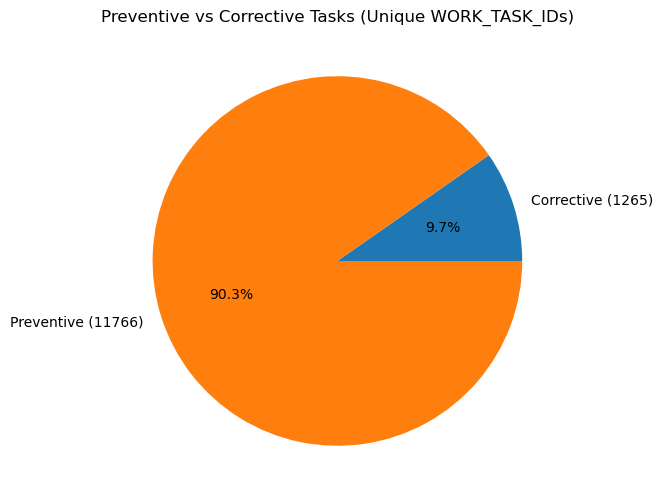

Number of unique tasks after dropping non-corrective tasks: 1265


In [3]:
import matplotlib.pyplot as plt


print(f"Number of unique tasks before cleaning: {df_tickets_assets['WORK_TASK_ID'].nunique()}")

print(f"Value counts before dropping na ASSET_IDs: {df_tickets_assets['WORK_TASK_STATUS_asset'].value_counts()}")


# Drop rows without an ASSET_ID
df_tickets_assets = df_tickets_assets.dropna(subset=['ASSET_ID'])

print(df_tickets_assets['WORK_TASK_STATUS_asset'].value_counts())

# Only keep completed tasks
df_tickets_assets = df_tickets_assets[
    # (df_tickets_assets['WORK_TASK_STATUS_ticket'] == 'Completed') # &
    (df_tickets_assets['WORK_TASK_STATUS_asset'] == 'Completed')
]


print(f"Number of unique tasks after dropping non-completed: {df_tickets_assets['WORK_TASK_ID'].nunique()}")


task_type_counts = df_tickets_assets.groupby('TASK_TYPE')['WORK_TASK_ID'].nunique()

plt.figure(figsize=(6, 6))
plt.pie(
    task_type_counts.values,
    labels=[f'{label} ({count})' for label, count in zip(task_type_counts.index, task_type_counts.values)],
    autopct='%1.1f%%'
)
plt.title('Preventive vs Corrective Tasks (Unique WORK_TASK_IDs)')
plt.show()




# Only keep corrective tasks
df_tickets_assets = df_tickets_assets[df_tickets_assets['TASK_TYPE'] == 'Corrective']
print(f"Number of unique tasks after dropping non-corrective tasks: {df_tickets_assets['WORK_TASK_ID'].nunique()}")



## Important Note

Here, we can clearly see that we don't have much data to work with! The amount of tasks that have:
1. Been completed,
2. Have an Asset ID, and 
3. Are corrective

is very small (1,265 unique tasks) compared with our original dataset (>200,000 unique tasks)

In [4]:
# Sort the DataFrame by ASSET_ID and BASELINE_START_LTZ for efficient processing
df_merged_assets_sorted = df_tickets_assets.sort_values(by=['ASSET_ID', 'BASELINE_START_LTZ']).reset_index(drop=True)

repeated_tasks_by_asset_list = []
num_days = pd.Timedelta(days=90) 

print(num_days)

# Group by ASSET_ID
for asset_id, group in df_merged_assets_sorted.groupby('ASSET_ID'):
    # Iterate through each task in the group
    for i in range(len(group)):
        current_task = group.iloc[i]
        current_task_time = current_task['BASELINE_START_LTZ']

        # Check subsequent tasks for repetition within 90 days
        # Start checking from the next task (i+1) within the same asset group
        subsequent_tasks = group.iloc[i+1:]
        for j in range(len(subsequent_tasks)):
            other_task = subsequent_tasks.iloc[j]
            other_task_time = other_task['BASELINE_START_LTZ']

            time_difference = other_task_time - current_task_time

            if pd.isna(time_difference): # Skip if time_difference is NaT
                continue

            if time_difference <= num_days:
                # If a subsequent task is found within 90 days, the current task is repetitive
                repeated_tasks_by_asset_list.append(current_task.to_dict())
                break  # Move to the next current_task, as this one is identified as repetitive
            elif time_difference > num_days:
                # Since tasks are sorted by time, if the current subsequent task is already
                # beyond 90 days, all further tasks will also be, so we can break early.
                break

# Create a new DataFrame from the identified repeated tasks
df_tickets_filtered_by_asset = pd.DataFrame(repeated_tasks_by_asset_list)

print(f"Found {len(df_tickets_filtered_by_asset)} repetitive tasks by asset within {num_days.days} days.")



90 days 00:00:00
Found 342 repetitive tasks by asset within 90 days.


# Create Charts of Assets that are repeated

Let's create an interactive .html that visualizes the number of 'repetitive tasks' (as defined in this notebook) for each asset name. 

This chart can be found as a .html file you can open in a browser inside `src/data-viz`.

*Note: You can hover over each bar to see its number of occurrances and location path on campus!*

In [11]:
import plotly.express as px
import pandas as pd

asset_recurrence_counts = df_tickets_filtered_by_asset['ASSET_NAME'].value_counts()

df_plot_asset_recurrence = pd.DataFrame({
    'ASSET_NAME': asset_recurrence_counts.index,
    'Recurrence Count': asset_recurrence_counts.values
})

asset_location_mapping = df_tickets_filtered_by_asset.groupby('ASSET_NAME')['ASSET_PRIMARY_LOCATION'].apply(
    lambda x: ', '.join(x.dropna().astype(str).unique())
).reset_index()

df_plot_asset_recurrence = pd.merge(df_plot_asset_recurrence, asset_location_mapping, on='ASSET_NAME', how='left')

fig = px.bar(
    df_plot_asset_recurrence,
    x='ASSET_NAME',
    y='Recurrence Count',
    title='Top 15 Assets by Repetitive Task Recurrence',
    color='Recurrence Count',
    color_continuous_scale=px.colors.sequential.Blues,
    labels={'ASSET_NAME': 'Asset Name', 'Recurrence Count': 'Number of Recurrences', 'ASSET_PRIMARY_LOCATION': 'Primary Location'},
    hover_data=['ASSET_PRIMARY_LOCATION']
)

fig.update_layout(
    xaxis_tickangle=-90,
    xaxis_title_standoff=25,
    height=700,
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(color='black')
)

fig.update_traces(marker_line_color='black', marker_line_width=1)

fig.show()

output_html_filename = '../data-viz/repetitive_tasks_by_asset_interactive.html'
fig.write_html(output_html_filename)



print(f"Interactive chart saved as '{output_html_filename}'.")
print("You can open this .html file in a browser for viewing.")

Interactive chart saved as '../data-viz/repetitive_tasks_by_asset_interactive.html'.
You can open this .html file in a browser for viewing.


## Create Chart of Repetitive Tasks by Building Name

Now, let's do this by building. Remember that we don't have that much data to work with since so many corrective tasks don't have `'ASSET_ID'`s attached.

Again, this chart can be found as a .html file you can open in a browser inside `src/data-viz`.

In [9]:
import plotly.express as px
import pandas as pd

building_counts = df_tickets_filtered_by_asset['BUILDING'].value_counts().sort_values(ascending=False)

# Create a temporary DataFrame with explicit column names for Plotly
df_plot = pd.DataFrame({
    'Building': building_counts.index,
    'Repeated Tasks': building_counts.values
})

# Create an interactive bar chart using Plotly Express
fig = px.bar(
    df_plot, # Pass the DataFrame
    x='Building',
    y='Repeated Tasks',
    title='Number of Repeated Tasks per Building (Interactive)',
    color='Repeated Tasks', # Use the column name for color, which appears in hover
    color_continuous_scale=px.colors.sequential.Viridis,
    labels={'Building': 'Building', 'Repeated Tasks': 'Number of Repeated Tasks'} # Labels for axis titles
)

# Update layout for better readability, especially with so many items
fig.update_layout(
    xaxis_tickangle=-90, # Rotate x-axis labels
    xaxis_title_standoff=25, # Add some space below the x-axis title
    height=700 # Increase chart height for better visibility
)

fig.show()

# Save the interactive chart as an HTML file
output_filename = '../data-viz/repeated_tasks_per_building_interactive.html'
fig.write_html(output_filename)

print(f"Interactive chart saved as '{output_filename}'.")
print("You can open this .html file in a browser for viewing.")

Interactive chart saved as '../data-viz/repeated_tasks_per_building_interactive.html'.
You can open this .html file in a browser for viewing.


## Conclusion

Clearly, this definition for 'repetitive tasks' is insufficient — the work tickets are just not tracked to specific assets in the case when they are corrective. 

**Thus, we should look for another proxy of determining what tasks are 'repetitive'**. We will experiment with a better method in `src/notebooks/repetitive_objects.ipynb`. 